<a href="https://colab.research.google.com/github/jdrubianog-crypto/ods-streamlit-app/blob/main/clasificacion_bbc_transformers_bert_magister.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación multi-clase de artículos de noticias de la BBC usando Transformers

Diego Fernando Becerra Zambrano

Andrea Johanna Tellez Acosta

Juan David Rubiano Granada



**Profesor:** Luis Felipe Giraldo Trujillo



**Materia:** Técnicas de Deep Learning  
**Maestría en Inteligencia Artificial**
**Modelo principal:** `bert-base-uncased` con `BertForSequenceClassification`  
**Dataset:** `jacopoferretti/bbc-articles-dataset`


Este notebook desarrolla un sistema completo de clasificación supervisada de artículos de noticias de la BBC usando transformers. Aunque el enunciado menciona clasificación multi-etiqueta, también indica que debe usarse `softmax`; por tanto, el problema se aborda como **clasificación multi-clase**, donde cada artículo se asigna a una única categoría temática principal.

El flujo incluye descarga del dataset, inspección de calidad, limpieza moderada, análisis exploratorio, codificación de etiquetas, partición estratificada, tokenización con BERT, fine tuning, evaluación global y por categoría, matriz de confusión, análisis de errores, guardado del modelo e inferencia sobre textos nuevos.

## 1. Preparación del entorno

Se instalan las librerías necesarias para descargar datos desde KaggleHub, procesar texto, entrenar un transformer y evaluar el modelo. El notebook está preparado para ejecutarse en Google Colab o Kaggle con GPU.

In [ ]:
!pip install -q kagglehub transformers datasets accelerate evaluate scikit-learn matplotlib seaborn pandas numpy torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

import kagglehub
import warnings
warnings.filterwarnings("ignore")

## 2. Reproducibilidad y verificación de GPU

En modelos de deep learning puede existir variabilidad entre ejecuciones. Se fija una semilla para reducirla y se verifica si el entorno cuenta con GPU, lo cual es recomendable para entrenar BERT.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {DEVICE}")

if DEVICE == "cuda":
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("No se detectó GPU. El entrenamiento puede ser considerablemente más lento.")

Dispositivo disponible: cuda
GPU detectada: Tesla T4


## 3. Descarga y localización del dataset

El conjunto de datos se descarga con la línea solicitada en la guía. Como el repositorio puede incluir varios archivos CSV, el código identifica automáticamente el archivo más adecuado para clasificación.

In [ ]:
dataset_path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print(f"Ruta local del dataset: {dataset_path}")

csv_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Archivos CSV encontrados:")
for file in csv_files:
    print(file)

selected_csv = None
for file in csv_files:
    if "bbc_text_cls" in file:
        selected_csv = file
        break

if selected_csv is None:
    for file in csv_files:
        if "bbc_news_text_complexity_summarization" in file:
            selected_csv = file
            break

if selected_csv is None:
    raise FileNotFoundError("No se encontró un CSV compatible con el proyecto.")

print(f"Archivo seleccionado: {selected_csv}")

100%|██████████| 5.50M/5.50M [00:00<00:00, 63.2MB/s]

Extracting files...


Ruta local del dataset: /root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16
Archivos CSV encontrados:
/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/bbc_news_text_complexity_summarization.csv
/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/archive/bbc_text_cls.csv
/root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/archive (2)/bbc-news-data.csv
Archivo seleccionado: /root/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/archive/bbc_text_cls.csv


## 4. Carga y estandarización de columnas

Se normalizan las columnas del dataset a `text` y `label`. Esto hace que el resto del pipeline funcione aun si el archivo seleccionado usa `labels`, `category` u otro nombre compatible.

In [ ]:
raw_df = pd.read_csv(selected_csv)
print(f"Dimensiones originales: {raw_df.shape}")
print("Columnas originales:", raw_df.columns.tolist())

if "text" in raw_df.columns:
    text_col = "text"
elif "article" in raw_df.columns:
    text_col = "article"
else:
    raise ValueError("No se encontró columna de texto.")

if "labels" in raw_df.columns:
    label_col = "labels"
elif "category" in raw_df.columns:
    label_col = "category"
elif "label" in raw_df.columns:
    label_col = "label"
else:
    raise ValueError("No se encontró columna de etiqueta.")

data = raw_df[[text_col, label_col]].copy()
data.columns = ["text", "label"]
data.head()

Dimensiones originales: (2225, 2)
Columnas originales: ['text', 'labels']


,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


## 5. Revisión de calidad de los datos

Antes de entrenar el modelo se revisan valores nulos, duplicados y distribución de categorías. Esta inspección es básica, pero necesaria para evitar entrenamientos sesgados o errores silenciosos en la codificación de etiquetas.

In [ ]:
print("Dimensiones iniciales:", data.shape)

print("\nValores nulos:")
print(data.isnull().sum())

print("\nDuplicados exactos:", data.duplicated().sum())

print("\nDistribución de categorías:")
print(data["label"].value_counts())

Dimensiones iniciales: (2225, 2)

Valores nulos:
text     0
label    0
dtype: int64

Duplicados exactos: 98

Distribución de categorías:
label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 6. Limpieza moderada del texto

No se eliminan stopwords ni se aplica stemming, porque BERT fue preentrenado con lenguaje natural y aprovecha información contextual. La limpieza se limita a normalizar saltos de línea, espacios redundantes y registros vacíos.

In [ ]:
def clean_text(text):
    text = str(text)

    # Reemplazar saltos de línea por espacio
    text = re.sub(r"\n+", " ", text)

    # Reemplazar múltiples espacios por uno solo
    text = re.sub(r"\s+", " ", text)

    return text.strip()

processed_df = data.copy()

processed_df["clean_text"] = processed_df["text"].apply(clean_text)

# Normalización de etiquetas
processed_df["label"] = (
    processed_df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Eliminación de nulos y textos vacíos
processed_df = processed_df.dropna(subset=["clean_text", "label"])
processed_df = processed_df[processed_df["clean_text"].str.len() > 0]

# Eliminación de duplicados
processed_df = processed_df.drop_duplicates(
    subset=["clean_text", "label"]
).reset_index(drop=True)

print("Dimensiones después de limpieza:", processed_df.shape)
processed_df.head()

Dimensiones después de limpieza: (2125, 3)


,text,label,clean_text
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,Ad sales boost Time Warner profit Quarterly pr...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,Dollar gains on Greenspan speech The dollar ha...
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,Yukos unit buyer faces loan claim The owners o...
3,High fuel prices hit BA's profits\n\nBritish A...,business,High fuel prices hit BA's profits British Airw...
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,Pernod takeover talk lifts Domecq Shares in UK...


## 7. Análisis exploratorio del corpus

Se explora el balance de clases y la longitud de los artículos. La longitud es relevante porque BERT tiene un límite de tokens. En este notebook se usa `MAX_LENGTH = 256`, una decisión que equilibra información y costo computacional.

In [ ]:
processed_df["word_count"] = processed_df["clean_text"].apply(lambda x: len(x.split()))
processed_df["char_count"] = processed_df["clean_text"].apply(len)

print("Resumen de longitud en palabras:")
print(processed_df["word_count"].describe())

print("\nDistribución porcentual por categoría:")
print((processed_df["label"].value_counts(normalize=True) * 100).round(2))

Resumen de longitud en palabras:
count    2125.000000
mean      384.115294
std       241.478609
min        89.000000
25%       245.000000
50%       331.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64

Distribución porcentual por categoría:
label
business         23.67
sport            23.67
politics         18.96
entertainment    17.36
tech             16.33
Name: proportion, dtype: float64


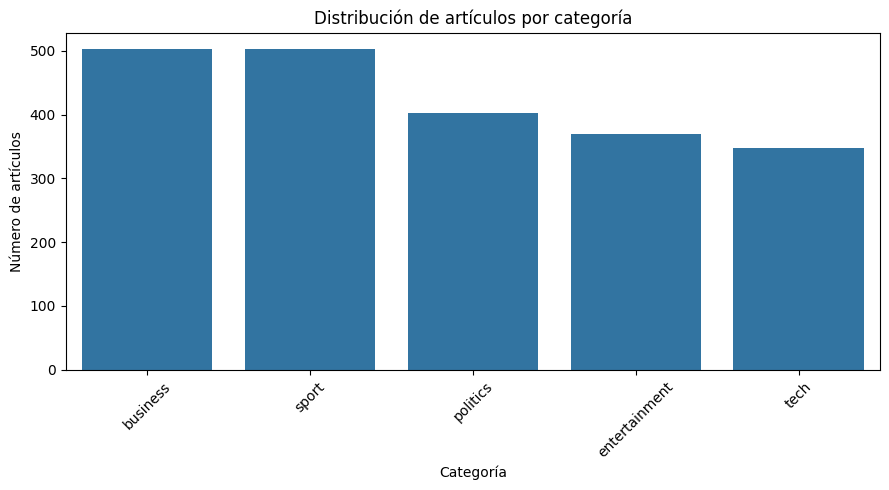

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(data=processed_df, x="label", order=processed_df["label"].value_counts().index)
plt.title("Distribución de artículos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de artículos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

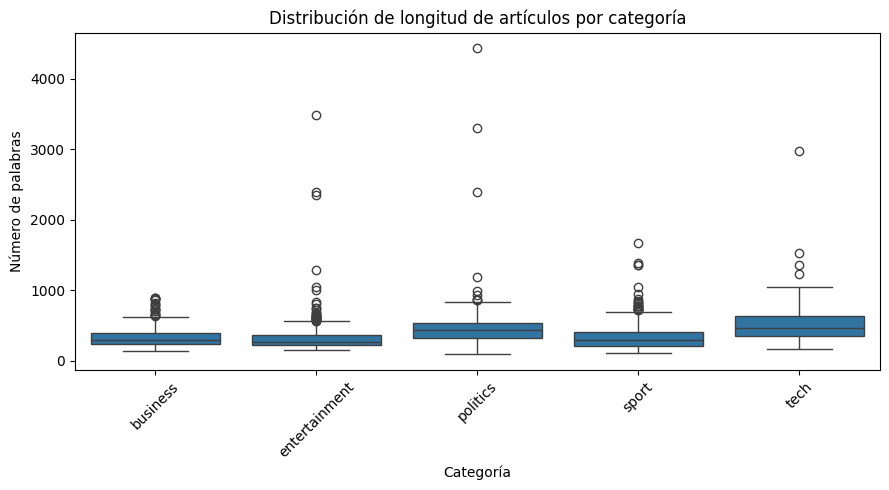

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=processed_df, x="label", y="word_count")
plt.title("Distribución de longitud de artículos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de palabras")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
length_summary = (
    processed_df
    .groupby("label")
    .agg(
        articles=("clean_text", "count"),
        avg_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        max_words=("word_count", "max")
    )
    .sort_values("articles", ascending=False)
)
length_summary.round(2)

,articles,avg_words,median_words,max_words
label,,,,
business,503,328.68,297.0,891
sport,503,330.42,291.0,1662
politics,403,456.22,439.0,4432
entertainment,369,332.71,262.0,3482
tech,347,513.24,460.0,2969


## 8. Codificación de etiquetas

Las categorías textuales se transforman en enteros. Además, se crean los diccionarios `id2label` y `label2id`, necesarios para que el modelo conserve la relación entre el índice numérico y la categoría original.

In [ ]:
label_encoder = LabelEncoder()
processed_df["label_id"] = label_encoder.fit_transform(processed_df["label"])

id2label = {idx: label for idx, label in enumerate(label_encoder.classes_)}
label2id = {label: idx for idx, label in id2label.items()}
num_labels = len(label_encoder.classes_)

print(f"Número de categorías: {num_labels}")
print("id2label:", id2label)
print("label2id:", label2id)

Número de categorías: 5
id2label: {0: 'business', 1: 'entertainment', 2: 'politics', 3: 'sport', 4: 'tech'}
label2id: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


## 9. División estratificada en entrenamiento, validación y prueba

Se usa una división 70 %, 15 % y 15 %. La estratificación mantiene proporciones similares de categorías en cada subconjunto, lo cual mejora la validez de la evaluación.

In [ ]:
train_df, temp_df = train_test_split(
    processed_df,
    test_size=0.30,
    random_state=SEED,
    stratify=processed_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"]
)

print("Entrenamiento:", train_df.shape)
print("Validación:", val_df.shape)
print("Prueba:", test_df.shape)

split_distribution = pd.DataFrame({
    "train": train_df["label"].value_counts(normalize=True),
    "validation": val_df["label"].value_counts(normalize=True),
    "test": test_df["label"].value_counts(normalize=True)
}).fillna(0) * 100

split_distribution.round(2)

Entrenamiento: (1487, 6)
Validación: (319, 6)
Prueba: (319, 6)


,train,validation,test
label,,,
business,23.67,23.51,23.82
entertainment,17.35,17.55,17.24
politics,18.96,18.81,19.12
sport,23.67,23.82,23.51
tech,16.34,16.30,16.30


## 10. Selección del transformer y tokenización

Se utiliza `bert-base-uncased`, adecuado para texto en inglés. La arquitectura final será `BertForSequenceClassification`, que añade una cabeza de clasificación sobre BERT. En clasificación multi-clase, la salida se interpreta con `softmax`, seleccionando la categoría con mayor probabilidad.

In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"Modelo base: {MODEL_NAME}")
print(f"Longitud máxima de tokens: {MAX_LENGTH}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Modelo base: bert-base-uncased
Longitud máxima de tokens: 256


## 11. Dataset personalizado para PyTorch

La clase siguiente permite entregar al `Trainer` textos tokenizados, máscaras de atención y etiquetas. El padding dinámico se delega en `DataCollatorWithPadding`, lo que reduce consumo de memoria frente a un padding fijo para todos los textos.

In [ ]:
class BBCNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length
        )
        encoding["labels"] = int(self.labels[idx])
        return encoding

train_dataset = BBCNewsDataset(train_df["clean_text"], train_df["label_id"], tokenizer, MAX_LENGTH)
val_dataset = BBCNewsDataset(val_df["clean_text"], val_df["label_id"], tokenizer, MAX_LENGTH)
test_dataset = BBCNewsDataset(test_df["clean_text"], test_df["label_id"], tokenizer, MAX_LENGTH)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Datasets preparados correctamente.")

Datasets preparados correctamente.


## 12. Inicialización de BERT para clasificación multi-clase

El número de salidas del modelo coincide con el número de categorías del dataset. Cada salida corresponde a un logit asociado a una categoría temática.

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.to(DEVICE)
print("Modelo cargado en el dispositivo de cómputo.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado en el dispositivo de cómputo.


## 13. Definición de métricas

Se calculan accuracy, precision, recall y F1. Se reportan promedios `macro` y `weighted`, porque el primero evalúa equilibrio entre clases y el segundo pondera según el tamaño de cada categoría.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

## 14. Configuración del entrenamiento

Se entrenan 4 épocas, dentro del rango solicitado de 2 a 5. La tasa de aprendizaje `2e-5` es habitual en fine tuning de BERT. Se incluye regularización y selección automática del mejor modelo con base en `f1_macro`.

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./bert_bbc_news_results",

    # Número de épocas (según lo solicitado en la guía)
    num_train_epochs=4,

    # Tamaño de batch (ajustable según GPU)
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # Parámetros de optimización
    learning_rate=2e-5,
    weight_decay=0.01,

    # Estrategias de evaluación y guardado
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    # Selección del mejor modelo
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    # Control de checkpoints
    save_total_limit=2,

    # Sin reportes externos (WandB, etc.)
    report_to="none",

    # Reproducibilidad
    seed=SEED,

    # Uso de GPU si está disponible
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    # El data_collator ahora gestiona padding dinámico
    data_collator=data_collator,

    # Métricas personalizadas
    compute_metrics=compute_metrics,

    # Early stopping para evitar sobreajuste
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Trainer configurado correctamente.")

Trainer configurado correctamente.


## 15. Entrenamiento del modelo

En esta etapa se realiza fine tuning. A diferencia de usar embeddings congelados, aquí se ajustan los pesos del transformer al dominio específico de los artículos de la BBC.

In [ ]:
train_output = trainer.train()
print("Entrenamiento finalizado.")
print(train_output)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.795093,0.178492,0.959248,0.958270,0.958571,0.956560,0.963149,0.959248,0.959615
2,0.088079,0.118004,0.971787,0.969866,0.971952,0.970117,0.973602,0.971787,0.972010
3,0.027857,0.110091,0.974922,0.974316,0.976464,0.975204,0.975308,0.974922,0.974955
4,0.018630,0.109464,0.978056,0.977926,0.979130,0.978433,0.978289,0.978056,0.978091


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Entrenamiento finalizado.
TrainOutput(global_step=372, training_loss=0.2324146327152047, metrics={'train_runtime': 245.1384, 'train_samples_per_second': 24.264, 'train_steps_per_second': 1.518, 'total_flos': 782513355687936.0, 'train_loss': 0.2324146327152047, 'epoch': 4.0})


## 16. Evaluación en validación y prueba

La validación permite observar el ajuste durante el entrenamiento. La prueba final se reserva para estimar el desempeño sobre artículos no vistos.

In [ ]:
val_metrics = trainer.evaluate(eval_dataset=val_dataset)
print("Métricas en validación:")
for key, value in val_metrics.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

Métricas en validación:
eval_loss: 0.1095
eval_accuracy: 0.9781
eval_precision_macro: 0.9779
eval_recall_macro: 0.9791
eval_f1_macro: 0.9784
eval_precision_weighted: 0.9783
eval_recall_weighted: 0.9781
eval_f1_weighted: 0.9781
eval_runtime: 1.5931
eval_samples_per_second: 200.2350
eval_steps_per_second: 12.5540
epoch: 4.0000


In [ ]:
test_metrics = trainer.evaluate(eval_dataset=test_dataset)
print("Métricas en prueba:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

Métricas en prueba:
eval_loss: 0.0522
eval_accuracy: 0.9906
eval_precision_macro: 0.9906
eval_recall_macro: 0.9897
eval_f1_macro: 0.9900
eval_precision_weighted: 0.9907
eval_recall_weighted: 0.9906
eval_f1_weighted: 0.9906
eval_runtime: 1.5445
eval_samples_per_second: 206.5350
eval_steps_per_second: 12.9490
epoch: 4.0000


## 17. Predicción, softmax y reporte por categoría

El modelo produce logits. Para obtener probabilidades interpretables, se aplica `softmax`. La categoría final corresponde al índice con mayor probabilidad.

In [ ]:
prediction_output = trainer.predict(test_dataset)
logits = prediction_output.predictions
true_labels = prediction_output.label_ids
predicted_labels = np.argmax(logits, axis=-1)
probabilities = F.softmax(torch.tensor(logits), dim=1).numpy()
print("Predicciones generadas sobre el conjunto de prueba.")

Predicciones generadas sobre el conjunto de prueba.


In [ ]:
target_names = label_encoder.classes_

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=target_names,
    digits=4,
    zero_division=0
))

report_dict = classification_report(
    true_labels,
    predicted_labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

               precision    recall  f1-score   support

     business     0.9868    0.9868    0.9868        76
entertainment     0.9821    1.0000    0.9910        55
     politics     0.9839    1.0000    0.9919        61
        sport     1.0000    1.0000    1.0000        75
         tech     1.0000    0.9615    0.9804        52

     accuracy                         0.9906       319
    macro avg     0.9906    0.9897    0.9900       319
 weighted avg     0.9907    0.9906    0.9906       319



,precision,recall,f1-score,support
business,0.986842,0.986842,0.986842,76.000000
entertainment,0.982143,1.000000,0.990991,55.000000
politics,0.983871,1.000000,0.991870,61.000000
sport,1.000000,1.000000,1.000000,75.000000
tech,1.000000,0.961538,0.980392,52.000000
accuracy,0.990596,0.990596,0.990596,0.990596
macro avg,0.990571,0.989676,0.990019,319.000000
weighted avg,0.990702,0.990596,0.990561,319.000000


## 18. Mejor y peor categoría según F1-score

Este análisis ayuda a identificar si el modelo aprende mejor unas categorías que otras. En noticias, algunas clases tienen vocabulario muy distintivo, mientras que otras pueden cruzarse temáticamente.

In [ ]:
category_report = report_df.loc[target_names].copy()

best_category = category_report["f1-score"].idxmax()
worst_category = category_report["f1-score"].idxmin()

print("Categoría con mejor desempeño:", best_category)
print(category_report.loc[best_category])

print("\nCategoría con menor desempeño:", worst_category)
print(category_report.loc[worst_category])

Categoría con mejor desempeño: sport
precision     1.0
recall        1.0
f1-score      1.0
support      75.0
Name: sport, dtype: float64

Categoría con menor desempeño: tech
precision     1.000000
recall        0.961538
f1-score      0.980392
support      52.000000
Name: tech, dtype: float64


## 19. Matriz de confusión

La matriz de confusión permite observar aciertos y errores por clase. Los valores de la diagonal representan predicciones correctas.

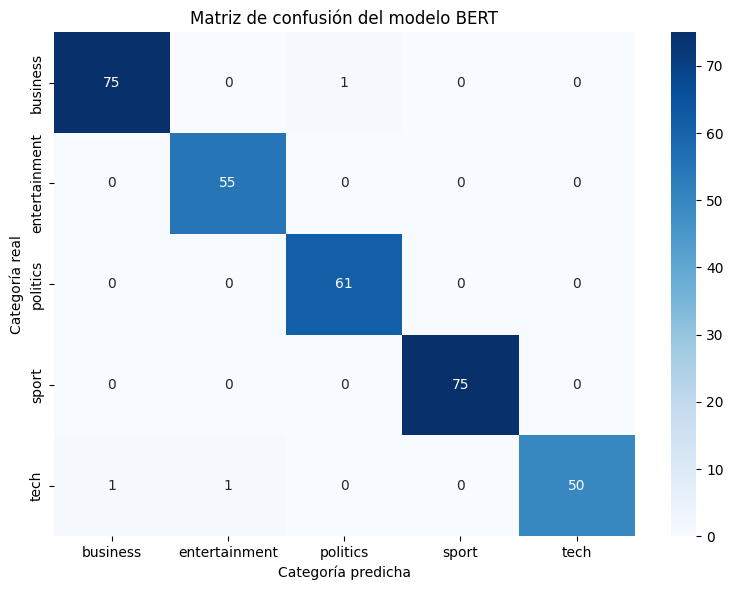

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.title("Matriz de confusión del modelo BERT")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")
plt.tight_layout()
plt.show()

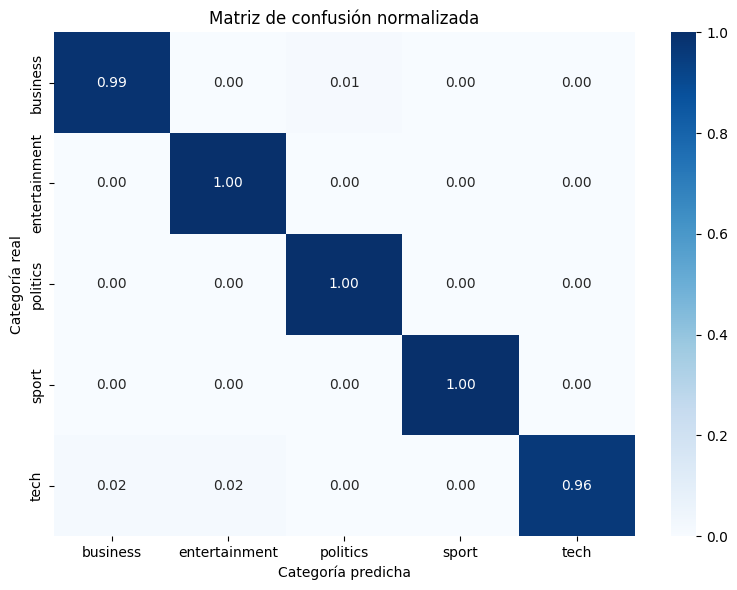

In [ ]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.title("Matriz de confusión normalizada")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")
plt.tight_layout()
plt.show()

## 20. Análisis de errores y confianza

Una evaluación más cuidadosa revisa los errores concretos. En especial, interesa observar fallos con alta confianza, porque pueden revelar ambigüedad temática, truncamiento del texto o cercanía semántica entre categorías.

In [ ]:
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df["real_label"] = [id2label[int(i)] for i in true_labels]
analysis_df["predicted_label"] = [id2label[int(i)] for i in predicted_labels]
analysis_df["confidence"] = probabilities.max(axis=1)
analysis_df["correct"] = analysis_df["real_label"] == analysis_df["predicted_label"]

analysis_df[["clean_text", "real_label", "predicted_label", "confidence", "correct"]].head()

,clean_text,real_label,predicted_label,confidence,correct
0,Wright-Phillips to start on right England coac...,sport,sport,0.995178,True
1,Federer breezes into semi-finals Roger Federer...,sport,sport,0.994949,True
2,Fox attacks Blair's Tory 'lies' Tony Blair lie...,politics,politics,0.994602,True
3,Tory candidate quits over remark A Conservativ...,politics,politics,0.994389,True
4,Hodges announces rugby retirement Scarlets and...,sport,sport,0.995021,True


In [ ]:
errors_df = analysis_df[analysis_df["correct"] == False].copy().sort_values("confidence", ascending=False)
print(f"Número total de errores en prueba: {len(errors_df)}")
errors_df[["clean_text", "real_label", "predicted_label", "confidence"]].head(10)

Número total de errores en prueba: 3


,clean_text,real_label,predicted_label,confidence
76,Golden rule 'intact' says ex-aide Chancellor G...,business,politics,0.992787
202,Web radio takes Spanish rap global Spin the ra...,tech,entertainment,0.979961
75,Who do you think you are? The real danger is n...,tech,business,0.964799


## 21. Probabilidades por categoría

Esta tabla muestra la distribución de probabilidad generada por `softmax`. Es útil para analizar si el modelo predice con alta seguridad o si duda entre categorías cercanas.

In [ ]:
probability_df = pd.DataFrame(probabilities, columns=target_names)
probability_df["real_label"] = analysis_df["real_label"]
probability_df["predicted_label"] = analysis_df["predicted_label"]
probability_df["confidence"] = analysis_df["confidence"]
probability_df.head()

,business,entertainment,politics,sport,tech,real_label,predicted_label,confidence
0,0.001065,0.001122,0.001313,0.995178,0.001323,sport,sport,0.995178
1,0.001211,0.001222,0.001204,0.994949,0.001413,sport,sport,0.994949
2,0.001098,0.001531,0.994602,0.001590,0.001178,politics,politics,0.994602
3,0.001152,0.001602,0.994389,0.001510,0.001347,politics,politics,0.994389
4,0.001204,0.001250,0.001310,0.995021,0.001215,sport,sport,0.995021


## 22. Guardado del modelo

Se guarda el modelo entrenado, el tokenizador y el mapeo de etiquetas. Esto permite reutilizar el clasificador sin volver a entrenarlo.

In [ ]:
save_path = "./bert_bbc_news_model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

with open(os.path.join(save_path, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f, indent=4)

print(f"Modelo guardado en: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: ./bert_bbc_news_model


## 23. Inferencia sobre nuevos artículos

La función siguiente clasifica textos nuevos aplicando el mismo flujo usado en entrenamiento: limpieza, tokenización, paso por BERT, softmax e identificación de la categoría con mayor probabilidad.

In [ ]:
def predict_news_category(text, model, tokenizer, id2label, max_length=256):
    cleaned = clean_text(text)
    inputs = tokenizer(cleaned, return_tensors="pt", truncation=True, padding=True, max_length=max_length)
    inputs = {key: value.to(model.device) for key, value in inputs.items()}
    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    predicted_id = int(torch.argmax(probs, dim=1).item())

    return {
        "predicted_label": id2label[predicted_id],
        "confidence": float(probs[0, predicted_id].item()),
        "probabilities": {id2label[i]: float(probs[0, i].item()) for i in range(len(id2label))}
    }

In [ ]:
new_article = (
    "The government announced new rules for digital platforms after several ministers argued "
    "that technology companies should be more transparent about data protection, online safety "
    "and the use of automated systems."
)

prediction = predict_news_category(new_article, model, tokenizer, id2label, MAX_LENGTH)

print("Categoría predicha:", prediction["predicted_label"])
print("Confianza:", round(prediction["confidence"], 4))

pd.DataFrame([prediction["probabilities"]]).T.rename(columns={0: "probability"}).sort_values("probability", ascending=False)

Categoría predicha: tech
Confianza: 0.9717


,probability
tech,0.971714
business,0.014014
politics,0.007859
entertainment,0.004616
sport,0.001797


## 24. Discusión técnica

La interpretación debe considerar tanto las métricas globales como el comportamiento por categoría. Si el F1-score macro se aproxima al F1-score ponderado, el rendimiento puede considerarse relativamente equilibrado. Si existe una distancia amplia entre ambos, habría indicios de que el modelo favorece categorías con mayor número de ejemplos.

BERT es pertinente para esta tarea porque no representa las palabras como unidades aisladas, sino en función del contexto. Esta característica ayuda a diferenciar artículos que comparten vocabulario superficial, aunque con límites evidentes. Una noticia sobre inversión en empresas tecnológicas, por ejemplo, puede contener señales de `business` y `tech`, pero el esquema multi-clase obliga a seleccionar una sola etiqueta.

También debe tenerse presente el efecto del truncamiento. Usar 256 tokens reduce el costo computacional, pero puede omitir información situada al final del artículo. Una mejora posible sería comparar 256 frente a 512 tokens, o aplicar estrategias por segmentos cuando los textos sean extensos.

## 25. Conclusión

El notebook cumple con los componentes solicitados en el proyecto: preprocesamiento, tokenización, adaptación de un transformer preentrenado, entrenamiento entre 2 y 5 épocas, evaluación con accuracy, precision, recall y F1-score, análisis por categoría, matriz de confusión, revisión de errores e inferencia sobre textos nuevos.

Desde una perspectiva de inteligencia artificial, el principal valor del enfoque está en transferir conocimiento lingüístico previamente aprendido por BERT hacia una tarea supervisada específica. En comparación con métodos clásicos basados en frecuencia de palabras, este modelo puede capturar mejor dependencias contextuales, aunque su rendimiento final depende de la calidad del dataset, la separación temática de las categorías, el balance de clases y las decisiones de entrenamiento.